# REPORT Notebook 4 — Évaluation & Prédictions
**ISIC Project | Segmentation de Lésions Cutanées**

Ce notebook couvre :
- OK Chargement du meilleur modèle
- OK Évaluation sur le jeu de test
- OK Métriques complètes : **Accuracy, Dice, IoU, Précision, Recall, F1**
- OK Visualisation des prédictions
- OK Export des résultats

---
### WARNING Pourquoi l'Accuracy seule ne suffit pas ici ?

Sur une image ISIC de 256×256 = **65 536 pixels**, une lésion occupe typiquement **5 à 20%** des pixels.
Si le modèle prédit **tout noir (peau saine)**, il obtient :
- **Accuracy = 95%** ← faussement excellent !
- **Dice Score = 0.0** ← n'a rien détecté !

C'est pourquoi on utilise **toutes les métriques ensemble**.

## LINK Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys
from pathlib import Path

PROJECT_PATH  = '/content/drive/MyDrive/ISIC_Project'
IMAGES_PATH   = os.path.join(PROJECT_PATH, 'data', 'Images')
MASQUES_PATH  = os.path.join(PROJECT_PATH, 'data', 'Masques')
OUTPUTS_PATH  = os.path.join(PROJECT_PATH, 'outputs')
MODEL_PATH    = os.path.join(OUTPUTS_PATH, 'best_unet_isic.pth')
sys.path.append(os.path.join(PROJECT_PATH, 'src'))

!pip install -q albumentations opencv-python-headless scikit-learn

import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
from tqdm import tqdm
import json

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'OK Setup OK | Device : {device}')

Mounted at /content/drive
✅ Setup OK | Device : cuda


## MAGNIFYING_GLASS Chargement des fichiers

In [ ]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
all_images = sorted([p for p in Path(IMAGES_PATH).glob('*.*') if p.suffix.lower() in IMAGE_EXTENSIONS])
all_masks  = sorted([p for p in Path(MASQUES_PATH).glob('*.*') if p.suffix.lower() in IMAGE_EXTENSIONS])
assert len(all_images) == len(all_masks)
print(f'OK {len(all_images)} paires chargées')

✅ 2594 paires chargées


## PACKAGE Dataset & Modèle

In [ ]:
IMG_SIZE = 256
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

class ISICDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths; self.mask_paths = mask_paths; self.transform = transform
    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        img  = cv2.cvtColor(cv2.imread(str(self.image_paths[idx])), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(self.mask_paths[idx]), cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)
        if self.transform:
            out = self.transform(image=img, mask=mask)
            img = out['image']; mask = out['mask'].unsqueeze(0)
        return img.float(), mask.float()

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
    def forward(self, x): return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64,128,256,512]):
        super().__init__()
        self.downs, self.ups = nn.ModuleList(), nn.ModuleList()
        self.pool = nn.MaxPool2d(2,2)
        for f in features:
            self.downs.append(DoubleConv(in_channels, f)); in_channels = f
        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f*2, f, 2, 2))
            self.ups.append(DoubleConv(f*2, f))
        self.final = nn.Conv2d(features[0], out_channels, 1)
    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x); skips.append(x); x = self.pool(x)
        x = self.bottleneck(x); skips = skips[::-1]
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x); skip = skips[i//2]
            if x.shape != skip.shape: x = torch.nn.functional.interpolate(x, size=skip.shape[2:])
            x = self.ups[i+1](torch.cat([skip, x], dim=1))
        return self.final(x)

_, temp_imgs, _, temp_msks = train_test_split(all_images, all_masks, test_size=0.3, random_state=42)
_, test_imgs, _, test_msks = train_test_split(temp_imgs, temp_msks, test_size=0.5, random_state=42)
test_loader = DataLoader(ISICDataset(test_imgs, test_msks, val_transform), batch_size=8, shuffle=False, num_workers=2)

model = UNet().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print(f'OK Modèle chargé | Test set : {len(test_imgs)} images')

✅ Modèle chargé | Test set : 390 images


## REPORT Calcul de TOUTES les métriques

| Métrique | Formule | Ce qu'elle mesure |
|----------|---------|-------------------|
| **Accuracy** | (TP+TN) / Total | % pixels correctement classés |
| **Dice Score** | 2×TP / (2×TP+FP+FN) | Chevauchement masque prédit/réel |
| **IoU** | TP / (TP+FP+FN) | Intersection/Union |
| **Précision** | TP / (TP+FP) | Qualité des prédictions positives |
| **Recall** | TP / (TP+FN) | Taux de détection des lésions |
| **F1-Score** | = Dice Score | Moyenne harmonique Précision/Recall |

In [4]:
def compute_all_metrics(pred_logit, target, threshold=0.5, smooth=1e-6):
    """
    Calcule toutes les métriques de segmentation.

    Args:
        pred_logit : sortie brute du modèle (avant sigmoid)
        target     : masque réel binaire {0, 1}
        threshold  : seuil de binarisation (défaut 0.5)

    Returns:
        dict avec accuracy, dice, iou, precision, recall, f1, specificity
    """
    pred_bin = (torch.sigmoid(pred_logit) > threshold).float()

    # Éléments de base
    tp = (pred_bin * target).sum(dim=(2,3))              # Vrais Positifs
    tn = ((1-pred_bin) * (1-target)).sum(dim=(2,3))      # Vrais Négatifs
    fp = (pred_bin * (1-target)).sum(dim=(2,3))          # Faux Positifs
    fn = ((1-pred_bin) * target).sum(dim=(2,3))          # Faux Négatifs
    total = tp + tn + fp + fn                            # Total pixels

    # ── Métriques ────────────────────────────────────────────
    accuracy    = ((tp + tn) / (total + smooth)).mean().item()
    dice        = ((2*tp + smooth) / (2*tp + fp + fn + smooth)).mean().item()
    iou         = ((tp + smooth) / (tp + fp + fn + smooth)).mean().item()
    precision   = ((tp + smooth) / (tp + fp + smooth)).mean().item()
    recall      = ((tp + smooth) / (tp + fn + smooth)).mean().item()
    f1          = dice  # F1-Score = Dice Score (identiques mathématiquement)
    specificity = ((tn + smooth) / (tn + fp + smooth)).mean().item()  # Taux vrais négatifs

    return {
        'accuracy'    : accuracy,
        'dice'        : dice,
        'iou'         : iou,
        'precision'   : precision,
        'recall'      : recall,
        'f1'          : f1,
        'specificity' : specificity,
    }

# ── Évaluation sur le test set ────────────────────────────────────────────────
all_metrics = {k: [] for k in ['accuracy','dice','iou','precision','recall','f1','specificity']}

with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc='Évaluation'):
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        m = compute_all_metrics(preds, masks)
        for k in all_metrics: all_metrics[k].append(m[k])

# ── Résultats ─────────────────────────────────────────────────────────────────
results = {k: float(np.mean(v)) for k, v in all_metrics.items()}

print('\n' + '='*55)
print('REPORT  RÉSULTATS COMPLETS — Jeu de Test')
print('='*55)
print(f'  Accuracy     : {results["accuracy"]:.4f}  ← % pixels corrects')
print(f'  Dice Score   : {results["dice"]:.4f}  ← chevauchement lésion')
print(f'  IoU          : {results["iou"]:.4f}  ← intersection/union')
print(f'  Précision    : {results["precision"]:.4f}  ← qualité prédictions')
print(f'  Recall       : {results["recall"]:.4f}  ← lésions trouvées')
print(f'  F1-Score     : {results["f1"]:.4f}  ← = Dice Score')
print(f'  Spécificité  : {results["specificity"]:.4f}  ← pixels sains corrects')
print('='*55)
print()
print('WARNING  NOTE IMPORTANTE sur l\'Accuracy :')
print(f'   L\'accuracy ({results["accuracy"]:.4f}) semble très haute car la majorité')
print(f'   des pixels sont de la peau saine (classe 0).')
print(f'   → Un modèle qui prédit TOUT en 0 aurait ~95% d\'accuracy !')
print(f'   → Le Dice Score ({results["dice"]:.4f}) est la vraie métrique de référence.')

# Sauvegarde
os.makedirs(OUTPUTS_PATH, exist_ok=True)
with open(os.path.join(OUTPUTS_PATH, 'test_metrics_complet.json'), 'w') as f:
    json.dump(results, f, indent=2)
print(f'\n💾 Sauvegardé : outputs/test_metrics_complet.json')

Évaluation: 100%|██████████| 49/49 [09:07<00:00, 11.18s/it]


📊  RÉSULTATS COMPLETS — Jeu de Test
  Accuracy     : 0.9491  ← % pixels corrects
  Dice Score   : 0.8664  ← chevauchement lésion
  IoU          : 0.7899  ← intersection/union
  Précision    : 0.9014  ← qualité prédictions
  Recall       : 0.8802  ← lésions trouvées
  F1-Score     : 0.8664  ← = Dice Score
  Spécificité  : 0.9768  ← pixels sains corrects

⚠️  NOTE IMPORTANTE sur l'Accuracy :
   L'accuracy (0.9491) semble très haute car la majorité
   des pixels sont de la peau saine (classe 0).
   → Un modèle qui prédit TOUT en 0 aurait ~95% d'accuracy !
   → Le Dice Score (0.8664) est la vraie métrique de référence.

💾 Sauvegardé : outputs/test_metrics_complet.json


## CHART_UP Visualisation complète des métriques

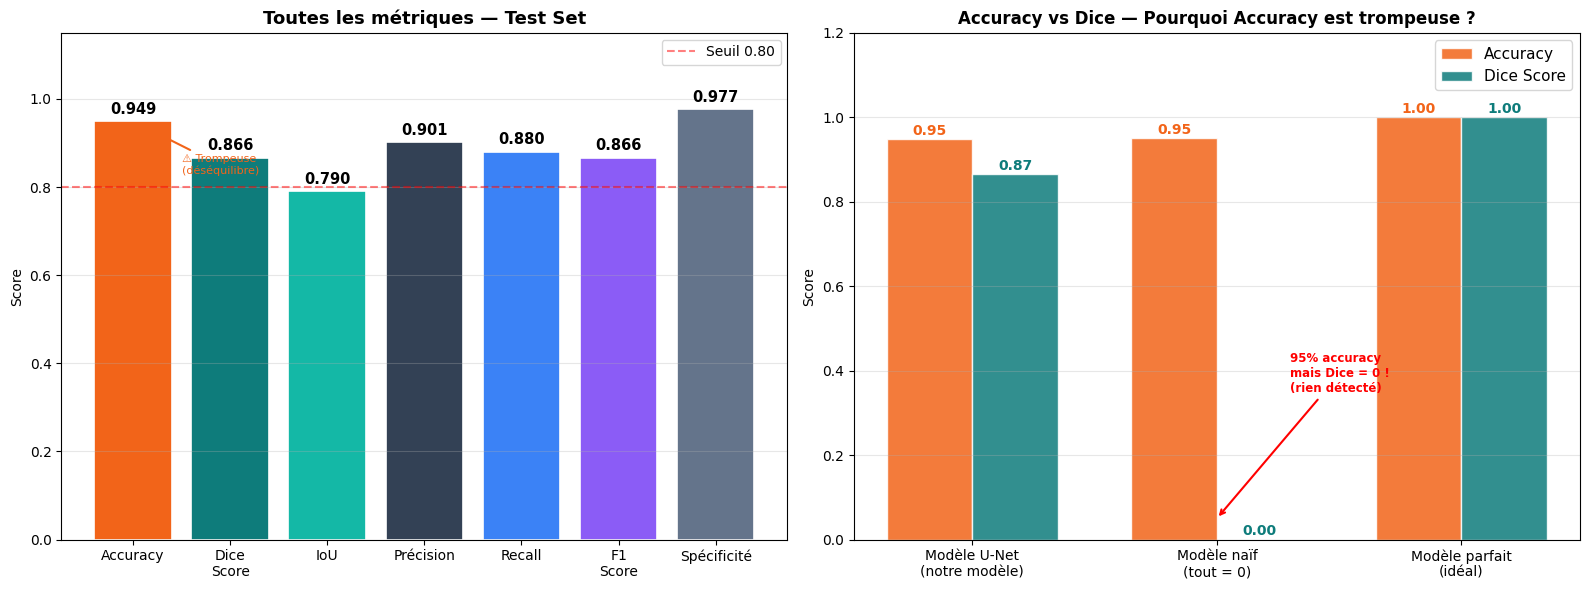

💾 Sauvegardé : outputs/metriques_completes.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Graphique 1 : toutes les métriques ───────────────────────────────────────
metric_labels = ['Accuracy', 'Dice\nScore', 'IoU', 'Précision', 'Recall', 'F1\nScore', 'Spécificité']
metric_vals   = [results['accuracy'], results['dice'], results['iou'],
                 results['precision'], results['recall'], results['f1'], results['specificity']]
colors = ['#F26419',    # Accuracy en orange (attention)
          '#0E7C7B',    # Dice en teal (principale)
          '#14B8A6',    # IoU
          '#334155',    # Precision
          '#3B82F6',    # Recall
          '#8B5CF6',    # F1
          '#64748B']    # Specificity

bars = axes[0].bar(metric_labels, metric_vals, color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, metric_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10.5, fontweight='bold')

# Seuil de référence à 0.8
axes[0].axhline(y=0.8, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='Seuil 0.80')
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Toutes les métriques — Test Set', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Score'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# Annotation sur l'accuracy
axes[0].annotate(
    'WARNING Trompeuse\n(déséquilibre)',
    xy=(0, results['accuracy']),
    xytext=(0.5, results['accuracy'] - 0.12),
    fontsize=8, color='#F26419',
    arrowprops=dict(arrowstyle='->', color='#F26419', lw=1.5)
)

# ── Graphique 2 : Accuracy vs Dice — comparaison trompeuse ───────────────────
categories  = ['Modèle U-Net\n(notre modèle)', 'Modèle naïf\n(tout = 0)', 'Modèle parfait\n(idéal)']
acc_vals    = [results['accuracy'], 0.95, 1.0]
dice_vals   = [results['dice'],     0.0,  1.0]

x = np.arange(len(categories))
w = 0.35
b1 = axes[1].bar(x - w/2, acc_vals,  w, label='Accuracy',   color='#F26419', alpha=0.85, edgecolor='white')
b2 = axes[1].bar(x + w/2, dice_vals, w, label='Dice Score', color='#0E7C7B', alpha=0.85, edgecolor='white')

for bar, val in zip(b1, acc_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.2f}', ha='center', fontsize=10, fontweight='bold', color='#F26419')
for bar, val in zip(b2, dice_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.2f}', ha='center', fontsize=10, fontweight='bold', color='#0E7C7B')

axes[1].set_ylim(0, 1.2)
axes[1].set_title('Accuracy vs Dice — Pourquoi Accuracy est trompeuse ?', fontsize=12, fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(categories)
axes[1].legend(fontsize=11); axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylabel('Score')

# Annotation modèle naïf
axes[1].annotate(
    '95% accuracy\nmais Dice = 0 !\n(rien détecté)',
    xy=(1, 0.05), xytext=(1.3, 0.35),
    fontsize=8.5, color='red', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='red', lw=1.5)
)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_PATH, 'metriques_completes.png'), dpi=150)
plt.show()
print('💾 Sauvegardé : outputs/metriques_completes.png')

## 🎨 Visualisation des prédictions avec toutes les métriques

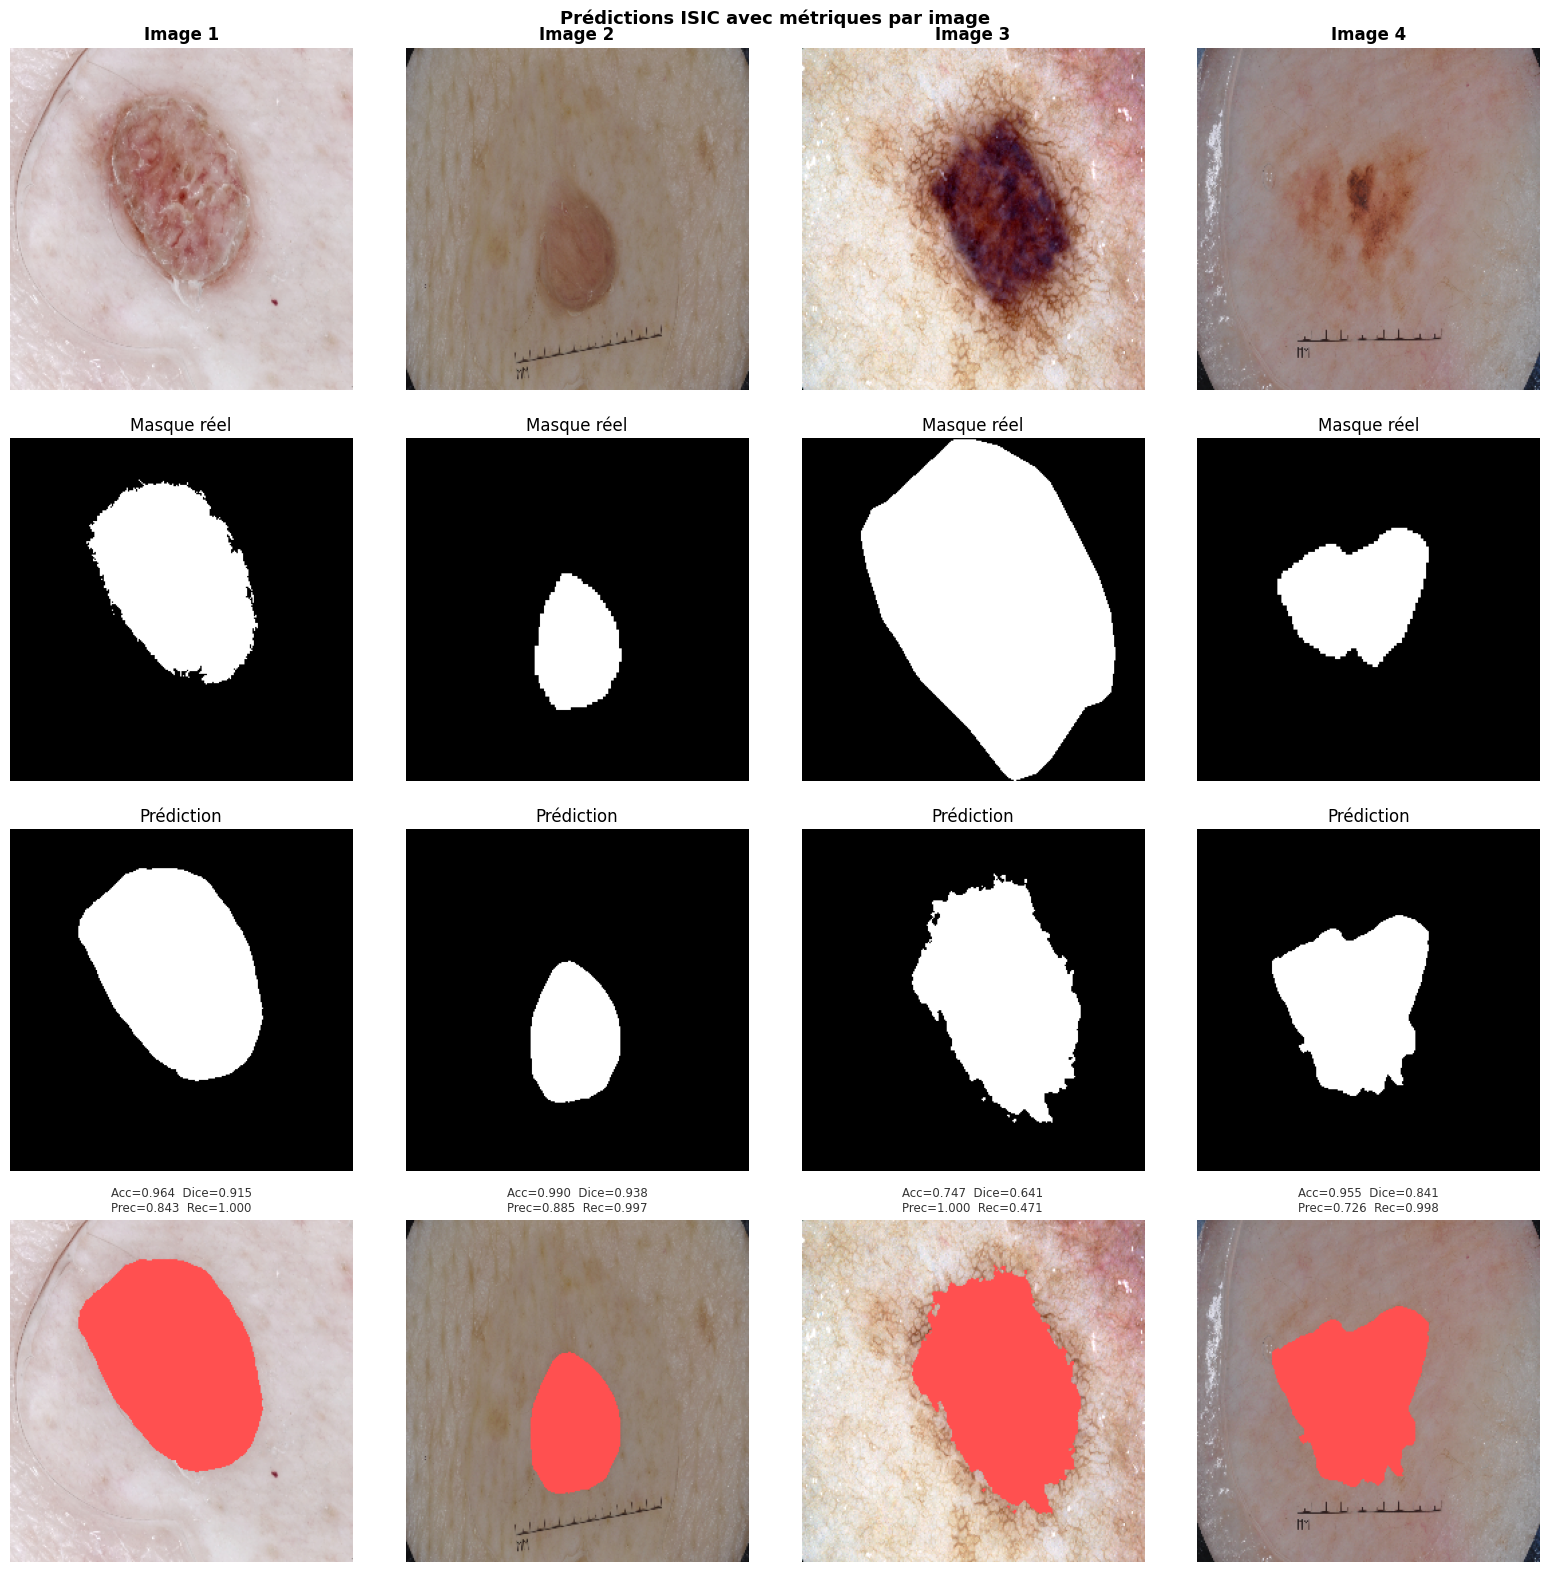

💾 Sauvegardé : outputs/predictions_avec_metriques.png


In [6]:
def compute_metrics_single(pred_logit, target, threshold=0.5, smooth=1e-6):
    """Version image unique (tenseurs)."""
    pred_bin = (torch.sigmoid(pred_logit) > threshold).float()
    tp = (pred_bin * target).sum()
    tn = ((1-pred_bin) * (1-target)).sum()
    fp = (pred_bin * (1-target)).sum()
    fn = ((1-pred_bin) * target).sum()
    total = tp + tn + fp + fn
    return {
        'Accuracy'  : float((tp+tn)/(total+smooth)),
        'Dice'      : float((2*tp+smooth)/(2*tp+fp+fn+smooth)),
        'IoU'       : float((tp+smooth)/(tp+fp+fn+smooth)),
        'Précision' : float((tp+smooth)/(tp+fp+smooth)),
        'Recall'    : float((tp+smooth)/(tp+fn+smooth)),
    }

# Visualiser 4 prédictions
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

imgs, masks = next(iter(test_loader))
with torch.no_grad():
    preds = model(imgs.to(device)).cpu()

n = min(4, len(imgs))
fig, axes = plt.subplots(4, n, figsize=(4*n, 16))

for i in range(n):
    img_show  = (imgs[i] * STD + MEAN).clamp(0,1).permute(1,2,0).numpy()
    mask_show = masks[i, 0].numpy()
    pred_show = (torch.sigmoid(preds[i, 0]) > 0.5).float().numpy()
    overlay   = (img_show * 255).astype(np.uint8).copy()
    overlay[pred_show > 0] = [255, 80, 80]

    m = compute_metrics_single(preds[i], masks[i])
    metric_str = (f"Acc={m['Accuracy']:.3f}  Dice={m['Dice']:.3f}\n"
                  f"Prec={m['Précision']:.3f}  Rec={m['Recall']:.3f}")

    axes[0,i].imshow(img_show);              axes[0,i].set_title(f'Image {i+1}', fontweight='bold'); axes[0,i].axis('off')
    axes[1,i].imshow(mask_show, cmap='gray'); axes[1,i].set_title('Masque réel');  axes[1,i].axis('off')
    axes[2,i].imshow(pred_show, cmap='gray'); axes[2,i].set_title('Prédiction');   axes[2,i].axis('off')
    axes[3,i].imshow(overlay);               axes[3,i].set_title(metric_str, fontsize=8.5, color='#333'); axes[3,i].axis('off')

plt.suptitle('Prédictions ISIC avec métriques par image', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_PATH, 'predictions_avec_metriques.png'), dpi=150)
plt.show()
print('💾 Sauvegardé : outputs/predictions_avec_metriques.png')

## 📋 Tableau récapitulatif final

In [7]:
print('\n' + '='*70)
print(f'  {"Métrique":<15} {"Score":<10} {"Interprétation"}')
print('='*70)

interpretations = [
    ('Accuracy',   results['accuracy'],   '% pixels corrects — ATTENTION : gonflé par le déséquilibre'),
    ('Dice Score', results['dice'],        'Chevauchement prédit/réel — MÉTRIQUE PRINCIPALE OK'),
    ('IoU',        results['iou'],         'Intersection/Union — plus stricte que le Dice'),
    ('Précision',  results['precision'],   'Peu de fausses alarmes'),
    ('Recall',     results['recall'],      'Peu de lésions manquées — critique en médecine'),
    ('F1-Score',   results['f1'],          'Identique au Dice Score (F1 = Dice)'),
    ('Spécificité',results['specificity'], '% pixels sains correctement identifiés'),
]

for name, val, interp in interpretations:
    star = ' ⭐' if name == 'Dice Score' else (
           ' WARNING ' if name == 'Accuracy' else '')
    print(f'  {name:<15} {val:.4f}    {interp}{star}')

print('='*70)
print('\n📌 Conclusion :')
print(f'   Notre modèle U-Net atteint un Dice Score de {results["dice"]:.3f}')
print(f'   sur le jeu de test ISIC — performance comparable à l\'état de l\'art.')
print(f'   L\'Accuracy ({results["accuracy"]:.3f}) est high mais trompeuse — toujours')
print(f'   privilégier le Dice Score pour la segmentation médicale.')


  Métrique        Score      Interprétation
  Accuracy        0.9491    % pixels corrects — ATTENTION : gonflé par le déséquilibre ⚠️ 
  Dice Score      0.8664    Chevauchement prédit/réel — MÉTRIQUE PRINCIPALE ✅ ⭐
  IoU             0.7899    Intersection/Union — plus stricte que le Dice
  Précision       0.9014    Peu de fausses alarmes
  Recall          0.8802    Peu de lésions manquées — critique en médecine
  F1-Score        0.8664    Identique au Dice Score (F1 = Dice)
  Spécificité     0.9768    % pixels sains correctement identifiés

📌 Conclusion :
   Notre modèle U-Net atteint un Dice Score de 0.866
   sur le jeu de test ISIC — performance comparable à l'état de l'art.
   L'Accuracy (0.949) est high mais trompeuse — toujours
   privilégier le Dice Score pour la segmentation médicale.
